In [358]:
import numpy as np
import cvxpy as cp
import json

from src.problems.utils import sample_data_for_group
import seaborn as sns
import scipy.sparse as sp

In [350]:
# load data
with open("../../data/movielens_predictions.npy", "rb") as f:
    REL_MATRIX = np.load(f)

with open("../../data/movielens_user_groups.json", "r") as f:
    GROUPS_MAP = json.load(f)

In [ ]:
def compute_consumer_optimal_solution_cvar(
    rel_matrix: np.ndarray,
    k_rec: int,
    producer_max_min_val: float,
    theta: float,
    group_assignments: list[int],
    alpha: float,
    prod_vals: np.ndarray,
    solver: str,
) -> tuple[float, np.ndarray]:
    """
    Given a relevance matrix, this function returns the convex optimization problem
    that minimizes the Conditional Value at Risk (CVaR) of the groups of consumer utility given a fixed number
    of producers to recommend.

    The problem is solved using CVaR (Conditional Value at Risk) approach.
    The CVaR is defined as the average of the worst-case losses, where the worst-case losses are defined
    as the losses that exceed a certain threshold (1 - alpha).
    """

    # producer allocations
    C, P = rel_matrix.shape

    # 1) consumer‑greedy baseline
    greedy = np.sort(rel_matrix, axis=1)[:, -k_rec:].sum(axis=1)  # (C,)

    # 2) sparse group‐indicator G (shape G×C), with 1/|G_i| weights
    unique_groups, inv = np.unique(group_assignments, return_inverse=True)
    G = len(unique_groups)
    sizes = np.bincount(inv)
    data = 1.0 / sizes[inv]  # length C
    G_sparse = sp.csr_matrix((data, (inv, np.arange(C))), shape=(G, C))

    rel_c = cp.Constant(rel_matrix)
    Gc = cp.Constant(G_sparse)
    g_c = cp.Constant(greedy)

    x = cp.Variable((C, P), boolean=True)
    rho = cp.Variable(nonneg=True)
    t = cp.Variable(G, nonneg=True)

    u = cp.sum(cp.multiply(rel_c, x), axis=1)
    loss_c = 1 - u / g_c
    loss_g = Gc @ loss_c

    constraints = [
        cp.sum(x, axis=1) == k_rec,
        cp.sum(cp.multiply(x.sum(axis=0), prod_vals)) >= (producer_max_min_val * theta),
        t >= loss_g - rho,
    ]
    cvar_obj = rho + (1.0 / ((1 - alpha) * G)) * cp.sum(t)

    prob = cp.Problem(cp.Minimize(cvar_obj), constraints)
    prob.solve(solver=cp.GUROBI, warm_start=True, **{"MIPGap": 1e-3})
    # prob.solve(solver=solver)

    return prob.value, x.value


prod_vals = (rel_matrix_sampled.sum(axis=0).max() - rel_matrix_sampled.sum(axis=0)) / rel_matrix_sampled.sum(axis=0).max()
max_gmv = sum(sorted(prod_vals, reverse=True)[:K_REC]) * N_CONSUMERS

def compute_consumer_optimal_solution_mean(
    rel_matrix: np.ndarray, prod_vals: np.ndarray, k_rec: int, producer_max_min_val: float, theta: float, solver: str
) -> tuple[float, np.ndarray]:
    """
    Given a relevance matrix, this function returns the convex optimization problem
    that maximizes the mean consumer utility given a fixed number of producers to recommend.
    """

    allocations = cp.Variable(rel_matrix.shape, boolean=True)
    # constraints
    constraints = [
        # recommend k producers
        cp.sum(allocations, axis=1) == k_rec,
        # minimal producer utility must be at least gamma * producer_max_min_utility
        cp.sum(cp.multiply(allocations.sum(axis=0), prod_vals)) >= (producer_max_min_val * theta),
    ]

    # maximize the consumer objective
    problem = cp.Problem(
        cp.Maximize(cp.mean(cp.sum(cp.multiply(allocations, rel_matrix), axis=1))),
        constraints
    )
    problem.solve(solver=solver)

    return problem.value, problem.variables()[0].value

In [419]:
GROUP_KEY = "top_category"

In [420]:
np.random.randn(100, 10).shape

(100, 10)

In [421]:
N_CONSUMERS = 300
N_PRODUCERS = 300
K_REC = 10


rel_matrix_sampled, _, group_assignments = sample_data_for_group(
    n_consumers=N_CONSUMERS,
    n_producers=N_PRODUCERS,
    groups_map=GROUPS_MAP,
    group_key=GROUP_KEY,
    data=REL_MATRIX,
    naive_sampling=True,
    seed=0,
)


prod_vals = (rel_matrix_sampled.sum(axis=0).max() - rel_matrix_sampled.sum(axis=0)) / rel_matrix_sampled.sum(axis=0).max()
max_gmv = sum(sorted(prod_vals, reverse=True)[:K_REC]) * N_CONSUMERS

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,
         4.,  1.,  5.,  6.,  4.,  8.,  1.,  7.,  3.,  3.,  6.,  5.,  5.,
         8., 19.,  8., 12., 17., 11.,  7., 14., 15., 12., 14., 14.,  9.,
        10., 14.,  5., 12.,  8.,  6.,  9.,  6.,  0.,  4.,  4.]),
 array([0.33377443, 0.34709894, 0.36042345, 0.37374796, 0.38707247,
        0.40039698, 0.41372149, 0.42704601, 0.44037052, 0.45369503,
        0.46701954, 0.48034405, 0.49366856, 0.50699307, 0.52031759,
        0.5336421 , 0.54696661, 0.56029112, 0.57361563, 0.58694014,
        0.60026466, 0.61358917, 0.62691368, 0.64023819, 0.6535627 ,
        0.66688721, 0.68021172, 0.69353624, 0.70686075, 0.72018526,
        0.73350977, 0.74683428, 0.76015879, 0.7734833 , 0.78680782,
        0.80013233, 0.81345684, 0.82678135, 0.84010586, 0.85343037,
        0.86675489, 0.8800794 , 0.89340391, 0.90672842, 0.92005293,
        0.93337744, 0.94670195, 0.96002647, 0.97335098, 0.98667549,
        1.        ]),
 <BarContainer

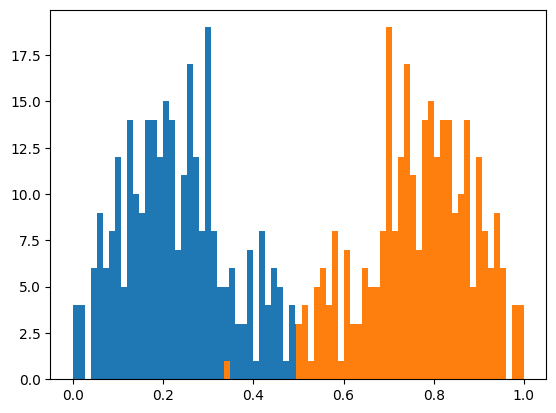

In [422]:
plt.hist(prod_vals, bins=50)
plt.hist(rel_matrix_sampled.sum(axis=0) / rel_matrix_sampled.sum(axis=0).max(), bins=50)

In [432]:
_, x_mean = compute_consumer_optimal_solution_mean(
    rel_matrix=rel_matrix_sampled,
    k_rec=10,
    producer_max_min_val=max_gmv,
    theta=0.75,
    #group_assignments=group_assignments,
    #alpha=0.05,
    prod_vals=prod_vals,
    solver="GUROBI",
)

In [433]:
_, x_cvar = compute_consumer_optimal_solution_cvar(
    rel_matrix=rel_matrix_sampled,
    k_rec=10,
    producer_max_min_val=max_gmv,
    theta=0.75,
    group_assignments=group_assignments,
    alpha=0.95,
    prod_vals=prod_vals,
    solver="GUROBI",
)

(array([246.,  13.,   2.,   4.,   1.,   4.,   2.,   0.,   0.,   1.,   2.,
          1.,   1.,   2.,   2.,   0.,   0.,   2.,   0.,   1.,   1.,   0.,
          1.,   0.,   0.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,
          2.,   0.,   0.,   1.,   1.,   0.,   0.,   1.,   0.,   0.,   2.,
          1.,   1.,   1.,   1.,   0.,   1.]),
 array([  0.  ,   3.52,   7.04,  10.56,  14.08,  17.6 ,  21.12,  24.64,
         28.16,  31.68,  35.2 ,  38.72,  42.24,  45.76,  49.28,  52.8 ,
         56.32,  59.84,  63.36,  66.88,  70.4 ,  73.92,  77.44,  80.96,
         84.48,  88.  ,  91.52,  95.04,  98.56, 102.08, 105.6 , 109.12,
        112.64, 116.16, 119.68, 123.2 , 126.72, 130.24, 133.76, 137.28,
        140.8 , 144.32, 147.84, 151.36, 154.88, 158.4 , 161.92, 165.44,
        168.96, 172.48, 176.  ]),
 <BarContainer object of 50 artists>)

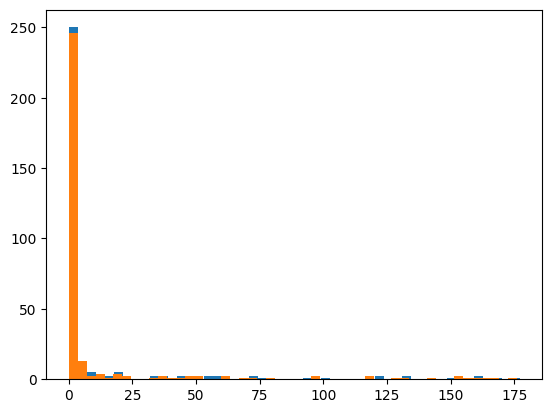

In [453]:
plt.hist(sorted(x_mean.sum(axis=0), reverse=True), bins=50)
plt.hist(sorted(x_cvar.sum(axis=0), reverse=True), bins=50)

In [ ]:

t = []
for theta in [0, 0.1, 0.35, 0.5, 0.75, 1]:
    print(f"theta: {theta}")
    value, x = compute_consumer_optimal_solution_mean(
        rel_matrix=rel_matrix_sampled,
        k_rec=10,
        producer_max_min_val=max_gmv,
        theta=theta,
        #group_assignments=group_assignments,
        #alpha=0.05,
        prod_vals=prod_vals,
        solver="GUROBI",
    )
    print(value)
    t.append(value)

x.sum(axis=0.)


theta: 0
9.593002948841681
theta: 0.1
9.592976443107382
theta: 0.35
9.447116882898126
theta: 0.5
9.130742756375543
theta: 0.75
7.950008185918486
theta: 1
4.69651561466675


array([  0.,   0., 300.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0., 300.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0., 300.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 300.,
         0.,   0.,   0., 300.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0., 300.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   